In [1]:
import astropy.constants as consts
import dill as pk
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
from astropy import units as u
from astropy.time import Time

import datetime as dt


from latcom.utils.optical_loading import pwv_interp
from latcom.utils.abscal_utils import bootstrap, bootstrap_err

import socolors

from pathlib import Path

# Display inline plots
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
# with open("../abscals/results_06262026.pk", "rb") as f:
with open("../../abscals/results_08212026.pk", "rb") as f:
    result_dict = pk.load(f)
with open("../../backups/results_12032025.pk", "rb") as f:
    old_result_dict = pk.load(f)
with open("../../data/r3v8_sim.pk", "rb") as f:
    sim = pk.load(f)


c_base = (220 / 255, 50 / 255, 32 / 255)
c_goal = (0 / 255, 90 / 255, 181 / 255)

In [3]:
labels = []
cals = []
obs = []
pwvs = []
data_omegas = []
fwhms = []
sources = []
times = []

pwv = pwv_interp()

freqs = ["030", "040", "090", "150", "220", "280"]
ufms = sorted(result_dict.keys())

for (
    freq
) in freqs:  # This is slighly inefficient but the ezest way to sort by freq then ufm
    for ufm in ufms:
        for key in result_dict.keys():
            if ufm not in key:
                continue
            for sub_key in result_dict[key].keys():
                if freq not in sub_key:
                    continue
                cur_cals = np.array(result_dict[key][sub_key]["cal"])
                cur_obs = np.array(result_dict[key][sub_key]["obs"])
                cur_omegas = np.array(result_dict[key][sub_key]["omega_data"])
                cur_sources = np.array(result_dict[key][sub_key]["source"])
                cur_fwhms = np.array(result_dict[key][sub_key]["fwhm"])
                cur_times = np.array(result_dict[key][sub_key]["time"])

                label = str(freq) + "_" + str(ufm)
                for j in range(len(cur_cals)):
                    cur_pwv = pwv(cur_obs[j].split("_")[2])
                    cals.append(cur_cals[j])
                    labels.append(label)
                    obs.append(cur_obs[j])
                    pwvs.append(cur_pwv)
                    data_omegas.append(cur_omegas[j])
                    sources.append(cur_sources[j].capitalize())
                    fwhms.append(cur_fwhms[j])
                    times.append(float(cur_times[j]))

labels = np.array(labels)
cals = np.array(cals)
obs = np.array(obs)
pwvs = np.array(pwvs)
data_omegas = np.array(data_omegas)
sources = np.array(sources)
fwhms = np.array(fwhms)
times = np.array(times)


df = pd.DataFrame(
    {
        "labels": labels,
        "cals": cals,
        "obs": obs,
        "pwvs": pwvs,
        "omegas": data_omegas,
        "sources": sources,
        "fwhms": fwhms,
        "times": times,
    }
)

In [24]:
pwv = pwv_interp()

t0 = Time("2025-04-26T00:00:00", format="isot", scale="utc")
tf = Time("2026-09-04T00:00:00", format="isot", scale="utc")
ndays = int(((tf-t0)/u.day).value)
days = np.linspace(t0, tf, ndays)

In [35]:
ndays

434

In [37]:
t_bins = pd.date_range(
    start="2025-04-26",
    end="2026-09-04",
    periods=15
)

In [40]:
result_dict = {}
#all_times = []
for label in labels:
    df_cur = df[df.labels == label]
    times = []
    for i in range(len(df_cur.times.to_numpy())):
        cur_time = dt.datetime.fromtimestamp(int(df_cur.times.to_numpy()[i]))
        times.append(cur_time)
        #all_times.append(cur_time)
    result_dict[label]={"times": np.array(times), "cals": df_cur.cals.to_numpy()/np.nanmean(df_cur.cals)}

In [83]:
ave_cals = []
ave_cal_errs = []
ts = []
for i in range(len(t_bins)-1):
    cur_cal = []
    for label in result_dict.keys():
        flag = np.where((t_bins[i] <= result_dict[label]["times"]) & (result_dict[label]["times"] < t_bins[i+1]) & (result_dict[label]["cals"] < 3))[0]
        cur_cal.extend(result_dict[label]["cals"][flag])
    ave_cals.append(np.nanmean(cur_cal))
    ave_cal_errs.append(np.std(cur_cal))
    ave_timestamp = (t_bins[i].timestamp() + t_bins[i+1].timestamp())/2
    ave_time = dt.datetime.fromtimestamp(ave_timestamp)
    ts.append(ave_time)
ave_cals = np.array(ave_cals)
ave_cal_errs = np.array(ave_cal_errs)

/tmp/ipykernel_2015294/1031881235.py:9: RuntimeWarning: Mean of empty slice
  ave_cals.append(np.nanmean(cur_cal))


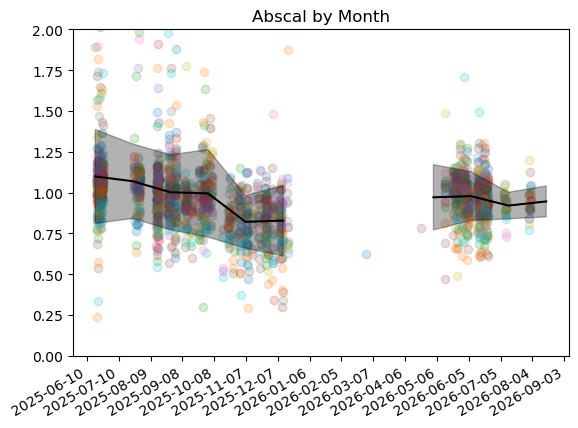

In [86]:
fig, ax = plt.subplots()
for label in result_dict.keys():
    ax.scatter(result_dict[label]["times"], result_dict[label]["cals"], label=label, alpha = 0.2)
ax.plot(ts, ave_cals, color="black")
ax.fill_between(ts, ave_cals-ave_cal_errs, ave_cals+ave_cal_errs, color="black", alpha = 0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=30))
plt.gcf().autofmt_xdate()

ax.set_ylim(0,2)

plt.title(f"Abscal by Month")
output_dir = Path(f"../../plts/abscals/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"monthy_abscals.pdf", dpi=600)
plt.savefig(output_dir / f"monthy_abscals.png", dpi=600)

plt.show()